In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Feature Engineered Dataset
file_path = r"C:/Users/aryan/Downloads/feature_engineered_nassau_candy.csv"

df = pd.read_csv(file_path)

df["Order Date"] = pd.to_datetime(df["Order Date"])

In [3]:
# Dataset Overview
print(df.head())

print(df.info())

print(df.describe())

   Row ID                      Order ID Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000 2024-01-03  2026-06-30   
1       2  US-2021-112326-CHO-TRI-54000 2024-01-04  2026-07-01   
2       3  US-2021-112326-CHO-NUT-13000 2024-01-04  2026-07-01   
3       4  US-2021-112326-CHO-SCR-58000 2024-01-04  2026-07-01   
4       5  US-2021-141817-CHO-TRI-54000 2024-01-05  2026-07-05   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code  ... Sales Per Unit Cost Per Unit Profit Per Unit  \
0       77095  ...           3.25          1.14            2.11   


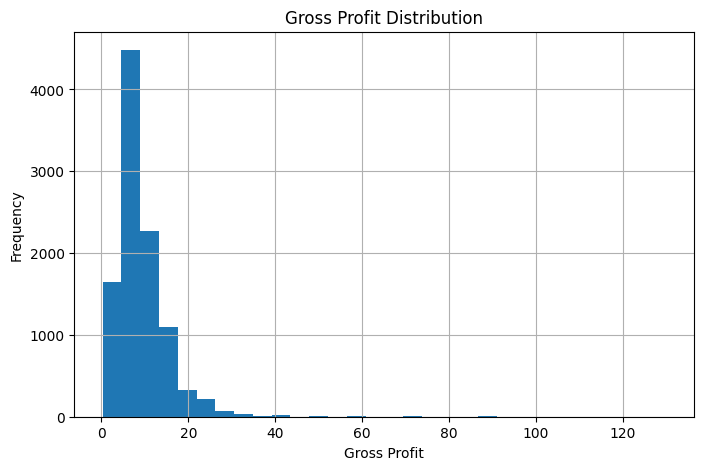

In [4]:
# Chart 1: Sales Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Gross Profit"], bins=30)

plt.title("Gross Profit Distribution")

plt.xlabel("Gross Profit")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

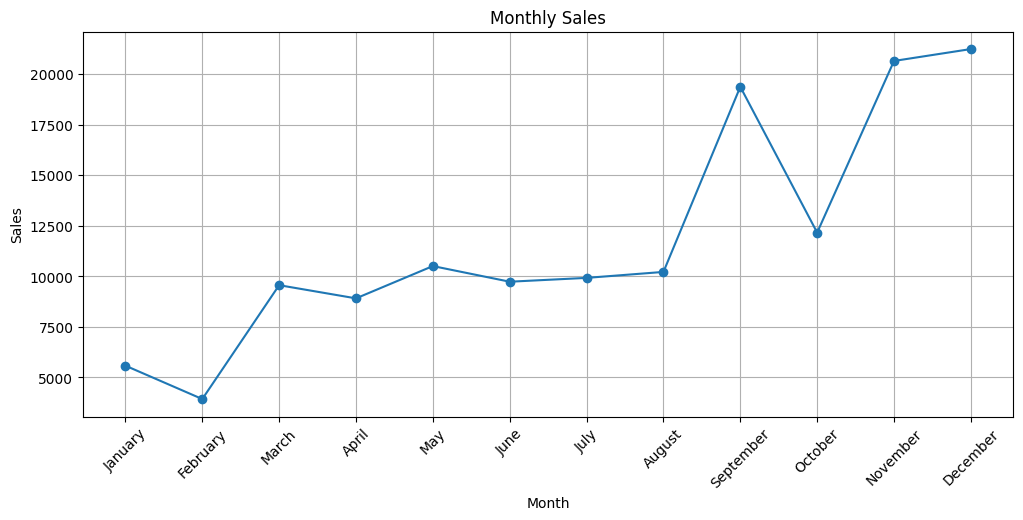

In [6]:
# Chart 3: Monthly Sales Trend

monthly_sales = df.groupby("Month Name")["Sales"].sum()

months = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = monthly_sales.reindex(months)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

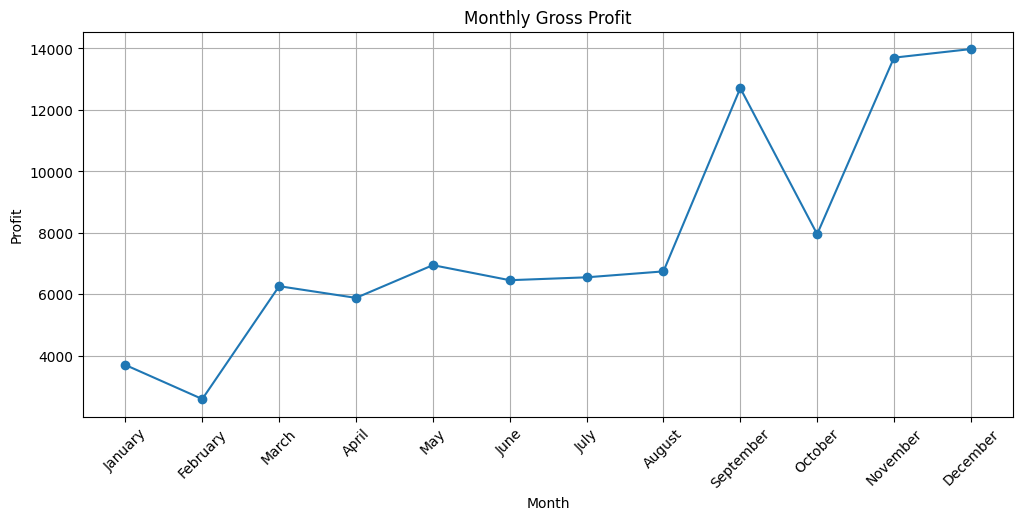

In [7]:
# Chart 4: Monthly Profit Trend

monthly_profit = df.groupby("Month Name")["Gross Profit"].sum()

monthly_profit = monthly_profit.reindex(months)

plt.figure(figsize=(12,5))

plt.plot(monthly_profit.index, monthly_profit.values, marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Gross Profit")

plt.xlabel("Month")

plt.ylabel("Profit")

plt.grid(True)

plt.show()

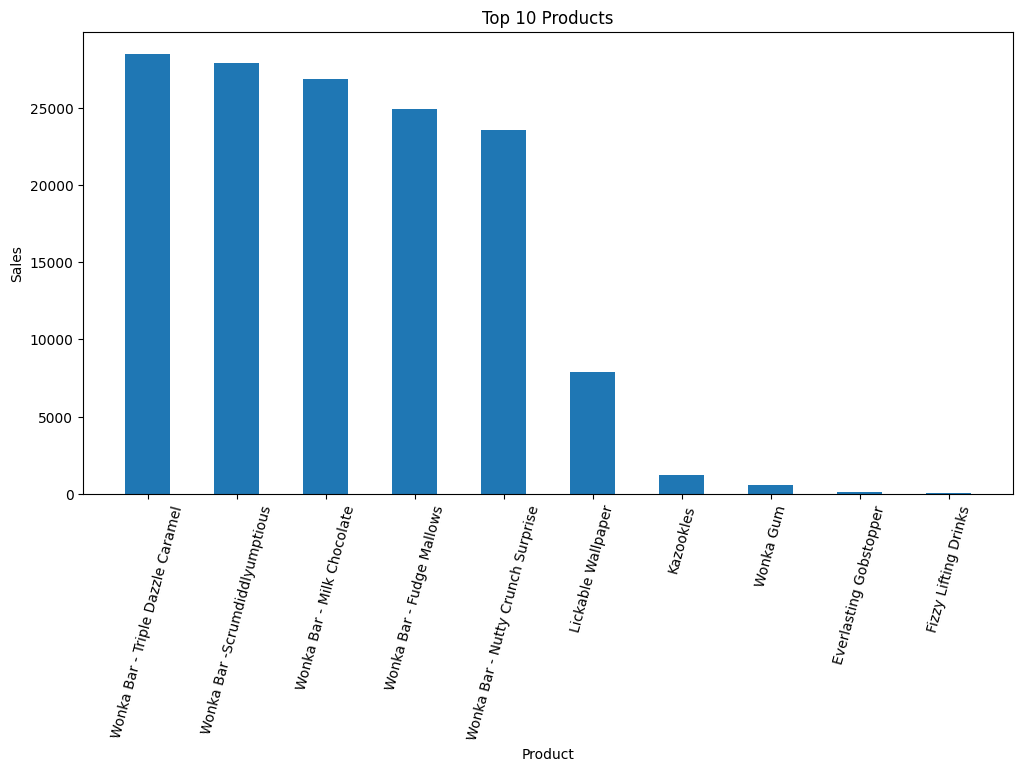

In [8]:
# Chart 5: Top 10 Products

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(top_products.index, top_products.values)

plt.xticks(rotation=75)

plt.title("Top 10 Products")

plt.xlabel("Product")

plt.ylabel("Sales")

plt.show()

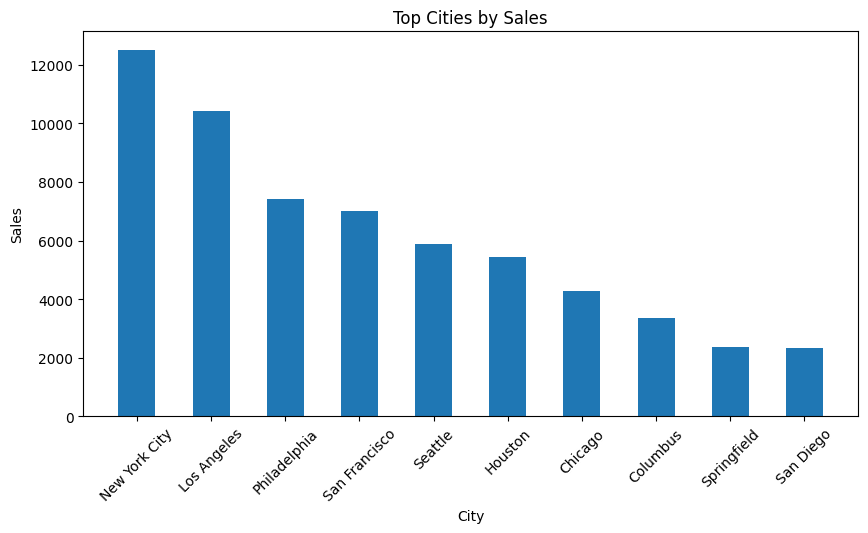

In [9]:
# Top 10 Cities

top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(top_cities.index, top_cities.values)

plt.xticks(rotation=45)

plt.title("Top Cities by Sales")

plt.xlabel("City")

plt.ylabel("Sales")

plt.show()

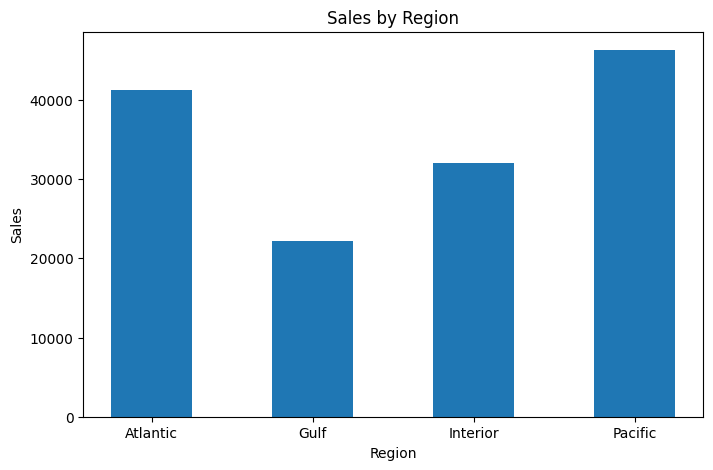

In [10]:
# Chart 7: Sales by Region

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

plt.bar(region_sales.index, region_sales.values)

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

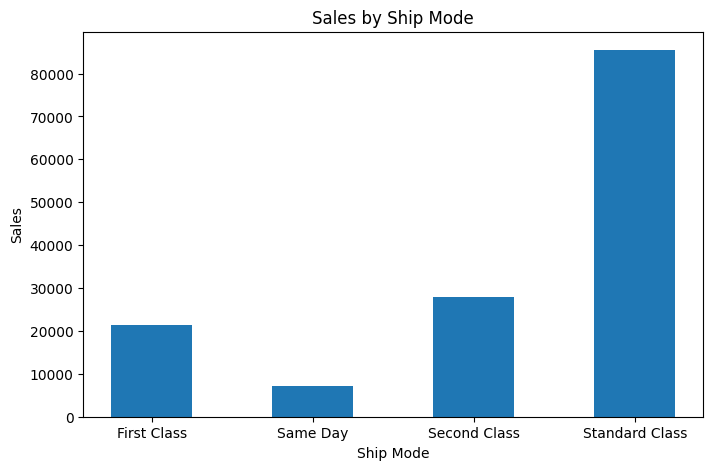

In [11]:
# Chart 8: Sales by Ship Mode

ship_mode = df.groupby("Ship Mode")["Sales"].sum()

plt.figure(figsize=(8,5))

plt.bar(ship_mode.index, ship_mode.values)

plt.title("Sales by Ship Mode")

plt.xlabel("Ship Mode")

plt.ylabel("Sales")

plt.show()

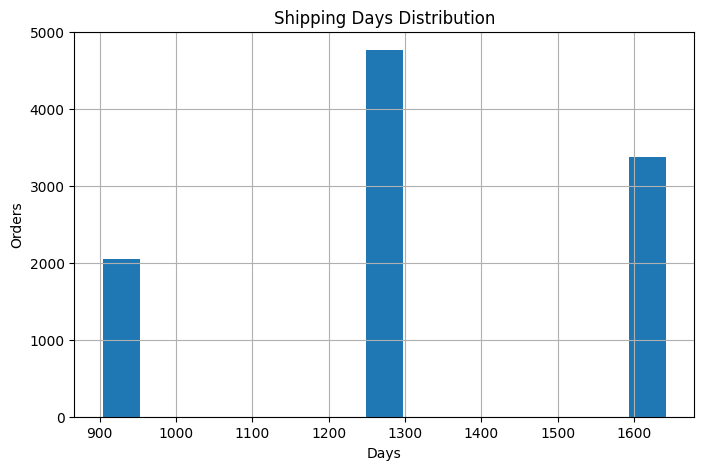

In [12]:
# Chart 9: Shipping Days Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Shipping Days"], bins=15)

plt.title("Shipping Days Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.grid(True)

plt.show()

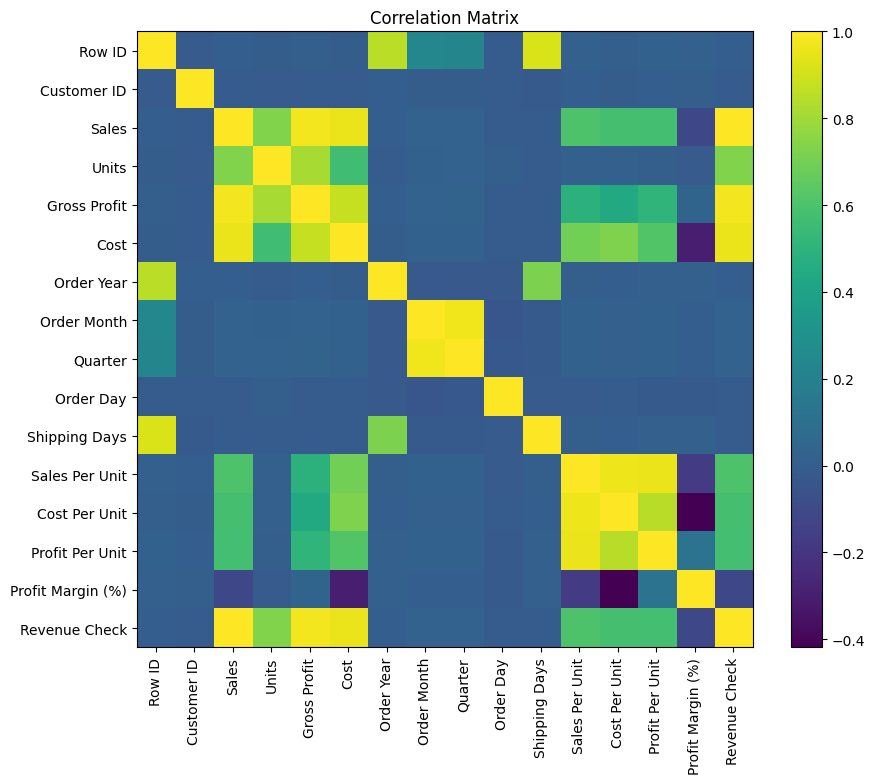

In [13]:
# Chart 10: Correlation Matrix

numeric = df.select_dtypes(include=["int64","float64"])

corr = numeric.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

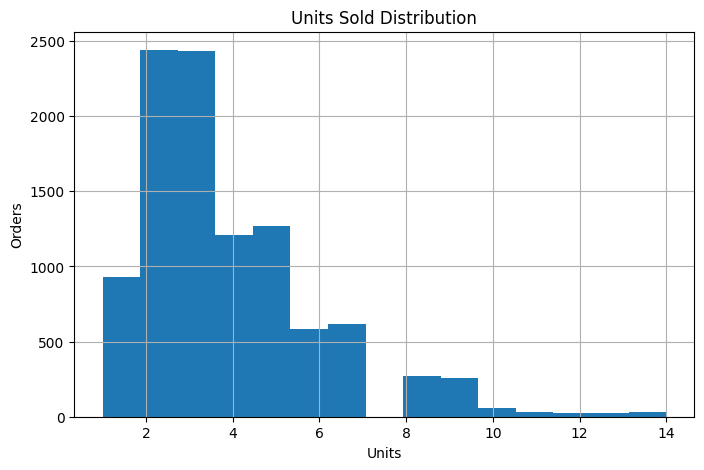

In [14]:
# Chart 11: Units Sold Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Units"], bins=15)

plt.title("Units Sold Distribution")

plt.xlabel("Units")

plt.ylabel("Orders")

plt.grid(True)

plt.show()

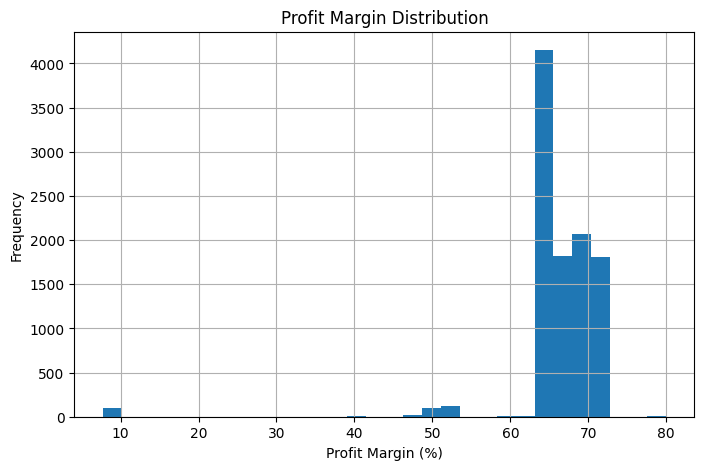

In [15]:
# Chart 12: Profit Margin Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Profit Margin (%)"], bins=30)

plt.title("Profit Margin Distribution")

plt.xlabel("Profit Margin (%)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [16]:
# Save All Charts

plt.savefig("sales_distribution.png")

<Figure size 640x480 with 0 Axes>

In [17]:
#  Export EDA Summary

eda_summary = pd.DataFrame({
    "Total Orders":[len(df)],
    "Total Sales":[df["Sales"].sum()],
    "Total Profit":[df["Gross Profit"].sum()],
    "Average Sales":[df["Sales"].mean()],
    "Average Profit":[df["Gross Profit"].mean()]
})

eda_summary.to_csv(
    r"C:/Users/aryan/Downloads/eda_summary.csv",
    index=False
)

print("EDA summary saved successfully.")

EDA summary saved successfully.
